In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
dataset_path = '/content/drive/MyDrive/animal-datasets'
print(os.listdir(dataset_path))

['archive']


In [ ]:
print(os.listdir(dataset_path + '/archive'))

['translate.py', 'raw-img']


In [ ]:
print(os.listdir(dataset_path + '/archive/raw-img'))

['cane', 'pecora', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'ragno', 'scoiattolo']


In [ ]:
final_dataset_path = '/content/drive/MyDrive/animal-datasets/archive/raw-img'

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

selected_classes = ['cane', 'gatto', 'elefante', 'cavallo', 'farfalla', 'ragno']

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2   # 80% train, 20% validation
)

train_data = datagen.flow_from_directory(
    final_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    classes=selected_classes,
    subset='training',
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    final_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    classes=selected_classes,
    subset='validation',
    class_mode='categorical'
)

Found 14069 images belonging to 6 classes.
Found 3515 images belonging to 6 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
!cp -r /content/drive/MyDrive/animal-datasets/archive/raw-img /content/raw-img

In [ ]:
import os
print(os.listdir('/content/raw-img'))

['pecora', 'farfalla', 'gatto', 'mucca', 'elefante', 'cavallo', 'scoiattolo', 'cane', 'ragno', 'gallina']


In [ ]:
final_dataset_path = '/content/raw-img'

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 282s 591ms/step - accuracy: 0.9258 - loss: 0.2220 - val_accuracy: 0.9596 - val_loss: 0.1204
Epoch 2/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 272s 518ms/step - accuracy: 0.9551 - loss: 0.1341 - val_accuracy: 0.9576 - val_loss: 0.1217
Epoch 3/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 231s 525ms/step - accuracy: 0.9635 - loss: 0.1059 - val_accuracy: 0.9624 - val_loss: 0.1145
Epoch 4/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 231s 524ms/step - accuracy: 0.9668 - loss: 0.1012 - val_accuracy: 0.9673 - val_loss: 0.0961
Epoch 5/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 228s 519ms/step - accuracy: 0.9696 - loss: 0.0899 - val_accuracy: 0.9644 - val_loss: 0.1059
Epoch 6/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 228s 518ms/step - accuracy: 0.9677 - loss: 0.0877 - val_accuracy: 0.9585 - val_loss: 0.1193
Epoch 7/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 231s 524ms/step - accuracy: 0.9689 - loss: 0.0870 - val_accuracy: 0.9613 - val_loss: 0.1162
Epoch 8/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 227s 516ms/step - accuracy: 0.9707 -

In [ ]:
model.save('/content/drive/MyDrive/animal-datasets/animal_classifier.h5')

In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/animal-datasets/animal_classifier.h5'))

True


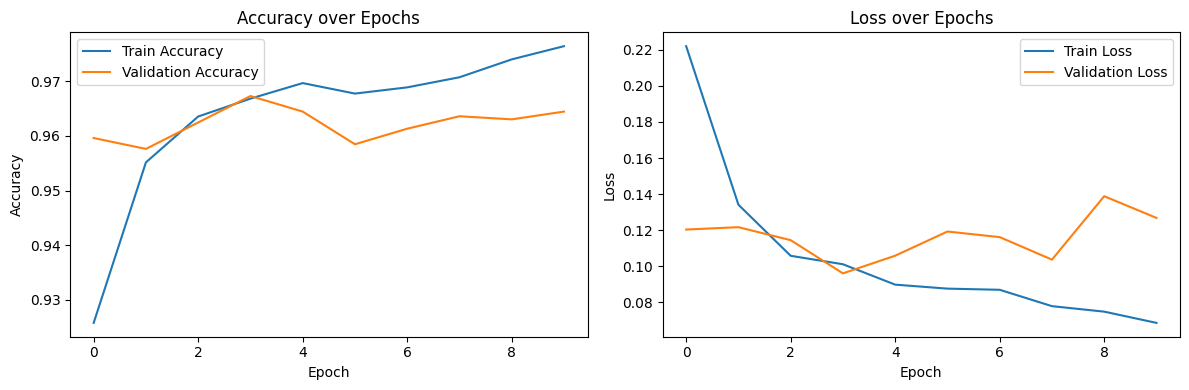

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/animal-datasets/accuracy_loss_graph.png')
plt.show()

110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 443ms/step


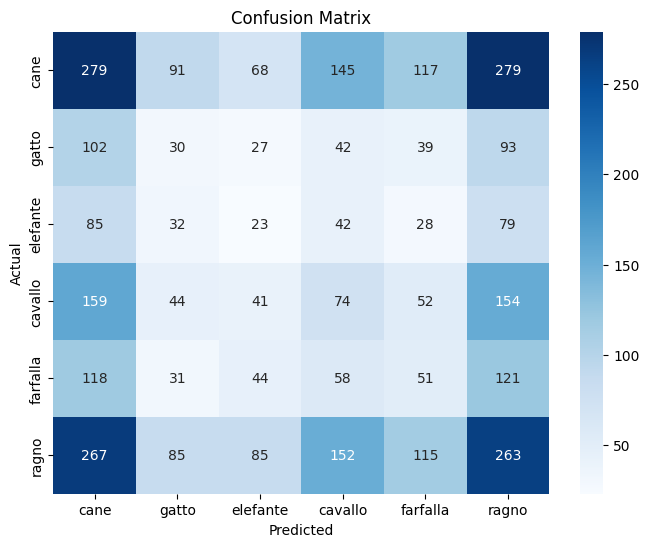

              precision    recall  f1-score   support

        cane       0.28      0.28      0.28       979
       gatto       0.10      0.09      0.09       333
    elefante       0.08      0.08      0.08       289
     cavallo       0.14      0.14      0.14       524
    farfalla       0.13      0.12      0.12       423
       ragno       0.27      0.27      0.27       967

    accuracy                           0.20      3515
   macro avg       0.16      0.16      0.16      3515
weighted avg       0.20      0.20      0.20      3515



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_data.reset()
predictions = model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/animal-datasets/confusion_matrix.png')
plt.show()

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

Found 3515 images belonging to 6 classes.
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step


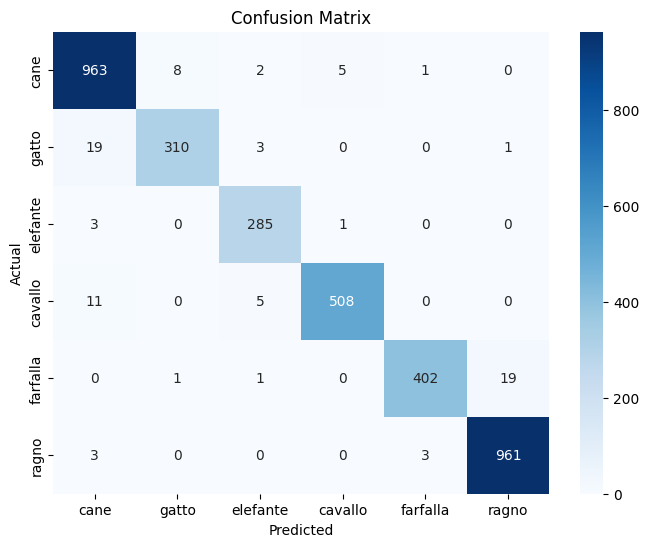

              precision    recall  f1-score   support

        cane       0.96      0.98      0.97       979
       gatto       0.97      0.93      0.95       333
    elefante       0.96      0.99      0.97       289
     cavallo       0.99      0.97      0.98       524
    farfalla       0.99      0.95      0.97       423
       ragno       0.98      0.99      0.99       967

    accuracy                           0.98      3515
   macro avg       0.98      0.97      0.97      3515
weighted avg       0.98      0.98      0.98      3515



In [ ]:
val_datagen_for_eval = ImageDataGenerator(rescale=1./255, validation_split=0.2)

eval_data = val_datagen_for_eval.flow_from_directory(
    final_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    classes=selected_classes,
    subset='validation',
    class_mode='categorical',
    shuffle=False   # important fix
)

predictions = model.predict(eval_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = eval_data.classes
class_labels = list(eval_data.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/animal-datasets/confusion_matrix.png')
plt.show()

print(classification_report(true_classes, predicted_classes, target_names=class_labels))


In [ ]:
!pip install streamlit -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 115.1 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

st.set_page_config(page_title="Animal Classifier", page_icon="🐾")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model('/content/drive/MyDrive/animal-datasets/animal_classifier.h5')

model = load_model()

class_labels = ['Dog', 'Cat', 'Elephant', 'Horse', 'Butterfly', 'Spider']
# order must match: cane, gatto, elefante, cavallo, farfalla, ragno

st.title("🐾 Animal Image Classifier")
st.write("Upload an animal image and the model will predict its category.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Uploaded Image', use_column_width=True)

    img = image.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    st.success(f"Prediction: **{predicted_class}**")
    st.info(f"Confidence: {confidence:.2f}%")

Writing app.py


In [ ]:
print(val_data.class_indices)

{'cane': 0, 'gatto': 1, 'elefante': 2, 'cavallo': 3, 'farfalla': 4, 'ragno': 5}


In [25]:
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧your url is: https://rich-towns-dream.loca.lt
^C


In [24]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

st.set_page_config(page_title="Animal Classifier", page_icon="🐾")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model('/content/drive/MyDrive/animal-datasets/animal_classifier.h5')

model = load_model()

class_labels = ['Dog', 'Cat', 'Elephant', 'Horse', 'Butterfly', 'Spider']

st.title("🐾 Animal Image Classifier")
st.write("Upload an animal image and the model will predict its category.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Uploaded Image', use_container_width=True)

    img = image.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    st.success(f"Prediction: **{predicted_class}**")
    st.info(f"Confidence: {confidence:.2f}%")

Overwriting app.py


In [26]:
!cp /content/app.py /content/drive/MyDrive/animal-datasets/app.py

In [27]:
print(os.listdir('/content/drive/MyDrive/animal-datasets'))

['archive', 'animal_classifier.h5', 'accuracy_loss_graph.png', 'confusion_matrix.png', 'app.py']


In [ ]:
# ===== QUICK DEMO CELL - VIVA WALE DIN SIRF YE CHALANA =====

from google.colab import drive
drive.mount('/content/drive')

!pip install streamlit -q
!npm install -g localtunnel -q

!pkill streamlit
!streamlit run /content/drive/MyDrive/animal-datasets/app.py &>/content/logs.txt &
!npx localtunnel --port 8501

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 1s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://fair-tires-send.loca.lt
